# Taller 7 - CNN para clasificar pósters por género

In [41]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [42]:
import random
import numpy as np
import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Keras: {keras.__version__}")

Keras: 3.14.0


In [43]:
import kagglehub
from pathlib import Path

path = Path(
    kagglehub.dataset_download("zulkarnainsaurav/four-genre-movie-poster-images")
)
print("Ruta descargada:", path)

Ruta descargada: /home/orpheezt/.cache/kagglehub/datasets/zulkarnainsaurav/four-genre-movie-poster-images/versions/2


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from keras import layers
import warnings

warnings.filterwarnings("ignore")

## 1) Exploración del dataset

In [45]:
DATA_DIR = Path(path) / "four_genre_posters" / "four_genre_posters"

/home/orpheezt/.cache/kagglehub/datasets/zulkarnainsaurav/four-genre-movie-poster-images/versions/2/four_genre_posters/four_genre_posters
Action: 337 imágenes
Comedy: 321 imágenes
Horror: 398 imágenes
Romance: 269 imágenes


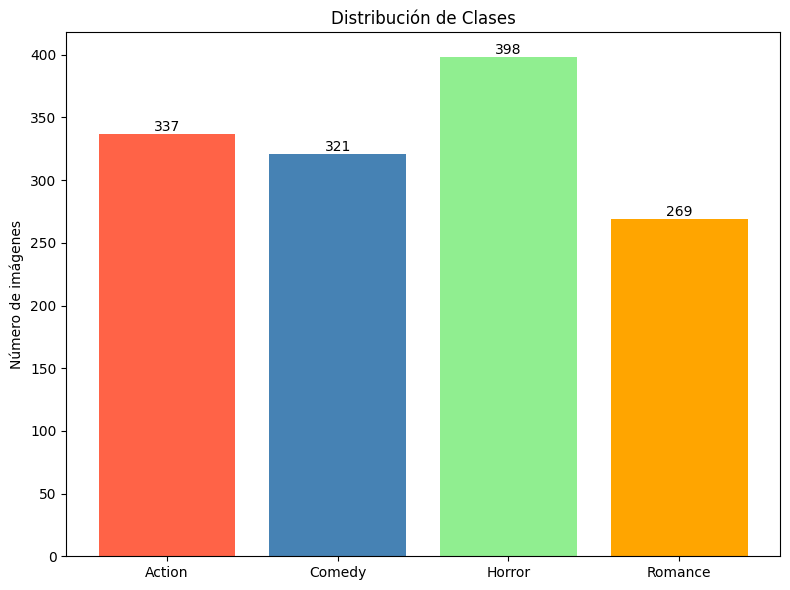

In [46]:
print(DATA_DIR)
IMG_SIZE = (380, 562)

action_paths = sorted(DATA_DIR.joinpath("Action").glob("*.jpg"))
comedy_paths = sorted(DATA_DIR.joinpath("Comedy").glob("*.jpg"))
horror_paths = sorted(DATA_DIR.joinpath("Horror").glob("*.jpg"))
romance_paths = sorted(DATA_DIR.joinpath("Romance").glob("*.jpg"))

n_action = len(action_paths)
n_comedy = len(comedy_paths)
n_horror = len(horror_paths)
n_romance = len(romance_paths)

print(f"Action: {n_action} imágenes")
print(f"Comedy: {n_comedy} imágenes")
print(f"Horror: {n_horror} imágenes")
print(f"Romance: {n_romance} imágenes")


_, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    ["Action", "Comedy", "Horror", "Romance"],
    [n_action, n_comedy, n_horror, n_romance],
    color=["tomato", "steelblue", "lightgreen", "orange"],
)
ax.set_title("Distribución de Clases")
ax.set_ylabel("Número de imágenes")
ax.bar_label(bars)
plt.tight_layout()
plt.show()

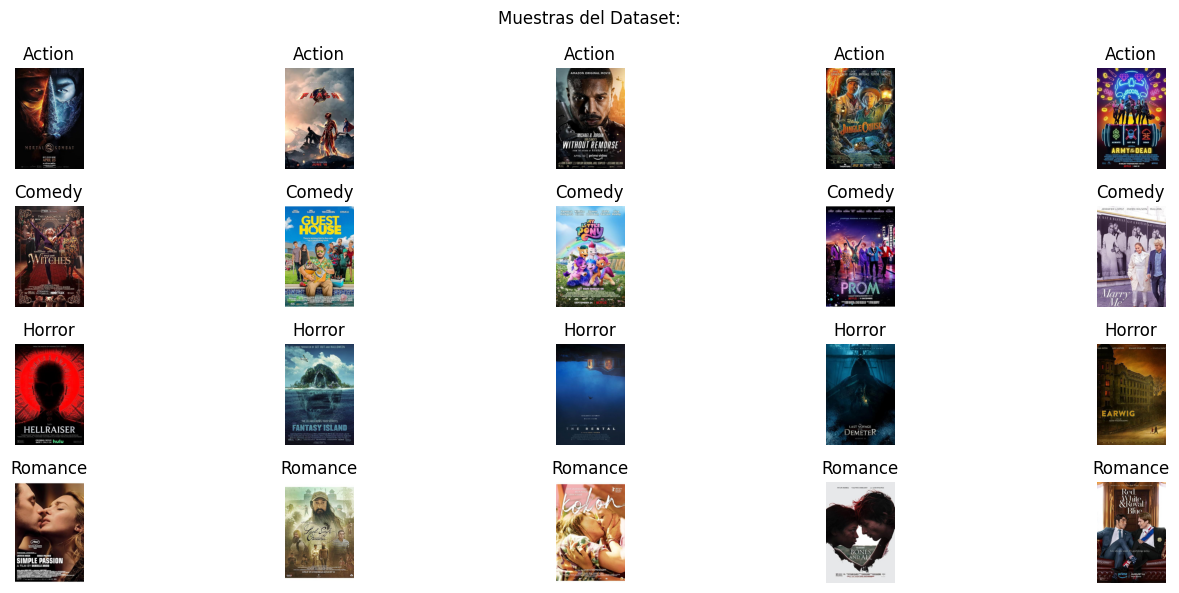

In [47]:
fig, axes = plt.subplots(4, 5, figsize=(15, 6))
fig.suptitle("Muestras del Dataset:")

for i in range(5):
    img = Image.open(action_paths[i]).convert("RGB")
    axes[0, i].imshow(img)
    axes[0, i].set_title("Action")
    axes[0, i].axis("off")

for i in range(5):
    img = Image.open(comedy_paths[i]).convert("RGB")
    axes[1, i].imshow(img)
    axes[1, i].set_title("Comedy")
    axes[1, i].axis("off")

for i in range(5):
    img = Image.open(horror_paths[i]).convert("RGB")
    axes[2, i].imshow(img)
    axes[2, i].set_title("Horror")
    axes[2, i].axis("off")

for i in range(5):
    img = Image.open(romance_paths[i]).convert("RGB")
    axes[3, i].imshow(img)
    axes[3, i].set_title("Romance")
    axes[3, i].axis("off")

plt.tight_layout()
plt.show()

# 3. Preprocesamiento de datos

Aplicamos 3 tecnicas, normalizacion, estandarizacion y aumentacion de datos.

Junto a la carga donde dividimos los datos de manera estratificada.

Con 15% test, 15% validacion y 85% entrenamiento

In [48]:
def load_dataset(
    action_paths, comedy_paths, horror_paths, romance_paths, img_size=(64, 64)
):
    imgs, labels = [], []
    for path in action_paths:
        img = Image.open(path).convert("RGB").resize(img_size)
        imgs.append(np.array(img, dtype=np.float32))
        labels.append([1, 0, 0, 0])
    for path in comedy_paths:
        img = Image.open(path).convert("RGB").resize(img_size)
        imgs.append(np.array(img, dtype=np.float32))
        labels.append([0, 1, 0, 0])
    for path in horror_paths:
        img = Image.open(path).convert("RGB").resize(img_size)
        imgs.append(np.array(img, dtype=np.float32))
        labels.append([0, 0, 1, 0])
    for path in romance_paths:
        img = Image.open(path).convert("RGB").resize(img_size)
        imgs.append(np.array(img, dtype=np.float32))
        labels.append([0, 0, 0, 1])
    return np.array(imgs), np.array(labels, dtype=np.float32)


X, y = load_dataset(action_paths, comedy_paths, horror_paths, romance_paths, IMG_SIZE)

In [49]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.18, random_state=42, stratify=y_temp
)

print(f"Conjunto de entrenamiento: {len(X_train)} imágenes {len(X_train) / len(X):.2%}")
print(f"Conjunto de validación: {len(X_val)} imágenes {len(X_val) / len(X):.2%}")
print(f"Conjunto de prueba: {len(X_test)} imágenes {len(X_test) / len(X):.2%}")

Conjunto de entrenamiento: 923 imágenes 69.66%
Conjunto de validación: 203 imágenes 15.32%
Conjunto de prueba: 199 imágenes 15.02%


Rango post-normalización: [0.0000, 1.0000]
Media global (train): 0.3925
Std global (train): 0.3333


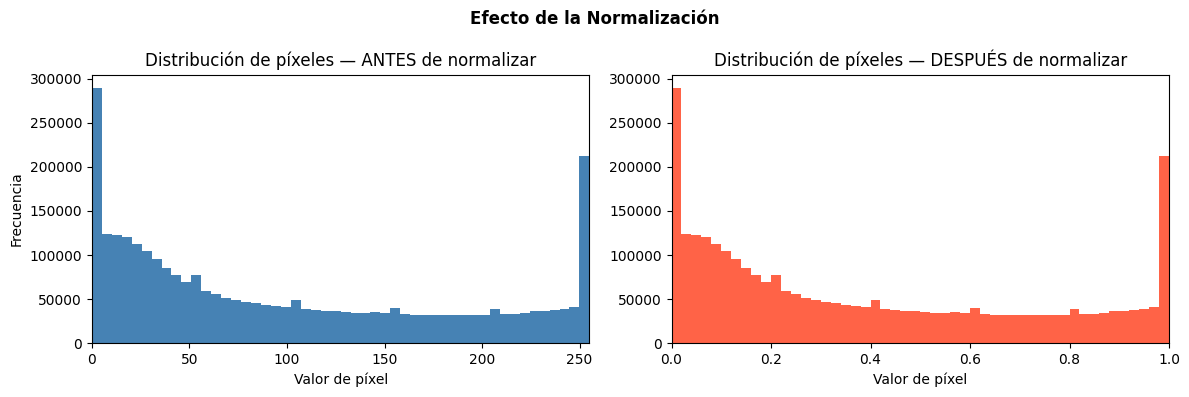

In [50]:
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

print(f"Rango post-normalización: [{X_train_norm.min():.4f}, {X_train_norm.max():.4f}]")
print(f"Media global (train): {X_train_norm.mean():.4f}")
print(f"Std global (train): {X_train_norm.std():.4f}")

_, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train.flatten()[::200], bins=50, color="steelblue")
axes[0].set_title("Distribución de píxeles — ANTES de normalizar")
axes[0].set_xlabel("Valor de píxel")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, 255)

axes[1].hist(X_train_norm.flatten()[::200], bins=50, color="tomato")
axes[1].set_title("Distribución de píxeles — DESPUÉS de normalizar")
axes[1].set_xlabel("Valor de píxel")
axes[1].set_xlim(0, 1)

plt.suptitle("Efecto de la Normalización", fontweight="bold")
plt.tight_layout()
plt.show()

In [51]:
std_layer = layers.Normalization(axis=-1, name="std_layer")
std_layer.adapt(X_train_norm.reshape(X_train_norm.shape[0], -1))

In [52]:
m_in = keras.Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3), name="input_img")

x = layers.RandomContrast(factor=0.10, name="random_contrast")(m_in)

x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="conv_1")(x)
x = layers.MaxPooling2D((2, 2), name="pool_1")(x)
x = layers.Dropout(0.20, name="dropout_1")(x)

x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_2")(x)
x = layers.MaxPooling2D((2, 2), name="pool_2")(x)
x = layers.Dropout(0.25, name="dropout_2")(x)

x = layers.Conv2D(128, (3, 3), padding="same", activation="relu", name="conv_3")(x)
x = layers.MaxPooling2D((2, 2), name="pool_3")(x)
x = layers.Dropout(0.30, name="dropout_3")(x)

x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dense(128, activation="relu", name="dense_cnn_1")(x)
x = layers.Dropout(0.40, name="dropout_dense")(x)

m_out = layers.Dense(4, activation="softmax", name="out")(x)

model = keras.Model(m_in, m_out, name="CNN_classificator_four_genres")
model.summary()

Model: "CNN_classificator_four_genres"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 562, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 562, 380, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 562, 380, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 281, 190, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 281, 190, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 281, 190, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 140, 95, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 140, 95, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 140, 95, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 70, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 70, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_cnn_1 (Dense)             │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
m_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
    keras.callbacks.CSVLogger(filename="train_log.csv", append=False),
]

In [54]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [ ]:
train_hist = model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    epochs=100,
    batch_size=64,
    callbacks=m_callbacks,
)

Epoch 1/100
